<a href="https://colab.research.google.com/github/Zelechos/Pragmatic_IA/blob/master/lang_graph/notebooks/003_Lang_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Condicional Graph

In [5]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [6]:
class State(TypedDict):
    number1: int
    number2: int
    operator: str
    result: int

### Nodo de Ejecucion de operaciones algebraicas

In [7]:

def add(state: State):
    return {"result": state["number1"] + state["number2"]}


def sub(state: State):
    return {"result": state["number1"] - state["number2"]}


def mul(state: State):
    return {"result": state["number1"] * state["number2"]}


def normal_division(state: State):
    return {"result": state["number1"] / state["number2"]}


def inverse_division(state: State):
    return {"result": state["number2"] / state["number1"]}


### Nodo de ruteo para eleccion de camino

In [8]:

def div_router_operation(state: State):
    if state["number1"] > state["number2"]:
        return "normal_division_operation"
    else:
        return "inverse_division_operation"

def router_operation(state: State):
    if state["operator"] == "+":
        return "add_operation"
    elif state["operator"] == "-":
        return "sub_operation"
    elif state["operator"] == "*":
        return "mul_operation"
    elif state["operator"] == "/":
        return "div_operation"




### Node que retorna el estado sirve para pasar el estado al nuestros nodos condicionales posteriormente actualizar el estado

In [9]:
def router_node(state: State):
    return state

### Construimos el Grafo y agregamos nuestros nodos

In [13]:
graph = StateGraph(State)


graph.add_node("add", add)
graph.add_node("sub", sub)
graph.add_node("mul", mul)
graph.add_node("nomal_div", normal_division)
graph.add_node("inverse_div", inverse_division)
graph.add_node("div", router_node) # Nodo para pasar el estado
graph.add_node("router", router_node) # Nodo para pasar el estado

### Agregamos nuestras transiciones y transiciones condicionales y compilamos nuestro grafo

In [14]:

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    router_operation,
    {
        "add_operation": "add",
        "sub_operation": "sub",
        "mul_operation": "mul",
        "div_operation": "div",
    },
)

graph.add_conditional_edges(
    "div",
    div_router_operation,
    {
        "normal_division_operation": "nomal_div",
        "inverse_division_operation": "inverse_div",
    },
)

graph.add_edge("add", END)
graph.add_edge("sub", END)
graph.add_edge("mul", END)
graph.add_edge("nomal_div", END)
graph.add_edge("inverse_div", END)

app = graph.compile()

### Pintamos la estructura de nuestro grafo

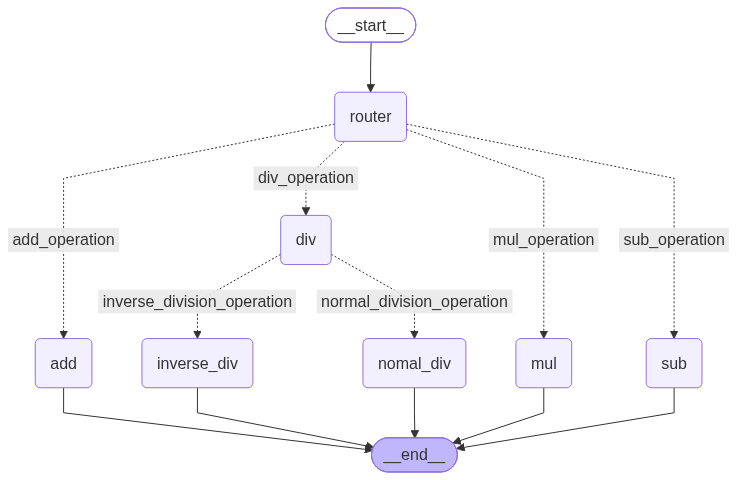

In [15]:
display(Image(app.get_graph().draw_mermaid_png()))

### Analisis y Resultados

In [16]:
response_in = State(number1=10, number2=5, operator="+")
response = app.invoke({"number1": 20, "number2": 10, "operator": "/"})

print(response["result"])
print(app.invoke(response_in))

2.0
{'number1': 10, 'number2': 5, 'operator': '+', 'result': 15}
